1. Problem Statement

Understanding the factors that influence student academic performance is critical for educators and policymakers.
This project analyses a dataset of **1000 students** across **8 features** (gender, ethnicity, parental education,
lunch type, test preparation, and three subject scores) to:

- Uncover patterns and trends through **Exploratory Data Analysis**
- Build **regression models** that predict a student's average score
- Identify the **most impactful features** driving performance

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import pickle
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')
print("All libraries imported ✓")

All libraries imported ✓


In [4]:
df = pd.read_csv(r'C:\Users\niksh\Downloads\archive (1)\StudentsPerformance.csv')
print(f"Dataset shape: {df.shape}")
df.head(10)

Dataset shape: (1000, 8)


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
5,female,group B,associate's degree,standard,none,71,83,78
6,female,group B,some college,standard,completed,88,95,92
7,male,group B,some college,free/reduced,none,40,43,39
8,male,group D,high school,free/reduced,completed,64,64,67
9,female,group B,high school,free/reduced,none,38,60,50


In [5]:
# Shape and types
print("Shape:", df.shape)
print("\nColumn Data Types:")
print(df.dtypes)

Shape: (1000, 8)

Column Data Types:
gender                         object
race/ethnicity                 object
parental level of education    object
lunch                          object
test preparation course        object
math score                      int64
reading score                   int64
writing score                   int64
dtype: object


In [6]:
# Missing values
print("Missing Values per Column:")
print(df.isnull().sum())

Missing Values per Column:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


In [7]:
# Duplicates
print(f"Duplicate rows: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)
print(f"Clean shape: {df.shape}")

Duplicate rows: 0
Clean shape: (1000, 8)


In [8]:
# Statistical summary
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


## 5. Feature Engineering — Average Score

We create a new target column **`average score`** as the mean of the three subject scores.
This becomes our regression target variable.

In [9]:
df['average score'] = (df['math score'] + df['reading score'] + df['writing score']) / 3
df['average score'] = df['average score'].round(2)
print("Average score range:", df['average score'].min(), "–", df['average score'].max())
df[['math score', 'reading score', 'writing score', 'average score']].head(8)

Average score range: 9.0 – 100.0


,math score,reading score,writing score,average score
0,72,72,74,72.67
1,69,90,88,82.33
2,90,95,93,92.67
3,47,57,44,49.33
4,76,78,75,76.33
5,71,83,78,77.33
6,88,95,92,91.67
7,40,43,39,40.67


## 6. Exploratory Data Analysis (EDA)

We analyse each feature against average performance to understand relationships.

### 6.1 Gender vs Average Score

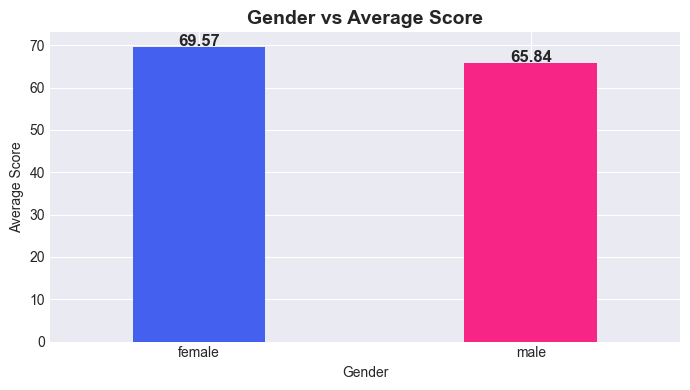

Interpretation: Female students show marginally higher average scores, driven by stronger reading & writing performance.


In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
gender_avg = df.groupby('gender')['average score'].mean()
gender_avg.plot(kind='bar', color=['#4361EE','#F72585'], ax=ax, width=0.4, edgecolor='none', rot=0)
for i, v in enumerate(gender_avg):
    ax.text(i, v + 0.3, f'{v:.2f}', ha='center', fontweight='bold', fontsize=12)
ax.set_title('Gender vs Average Score', fontsize=14, fontweight='bold')
ax.set_xlabel('Gender'); ax.set_ylabel('Average Score')
plt.tight_layout(); plt.show()
print("Interpretation: Female students show marginally higher average scores, driven by stronger reading & writing performance.")

### 6.2 Test Preparation vs Average Score

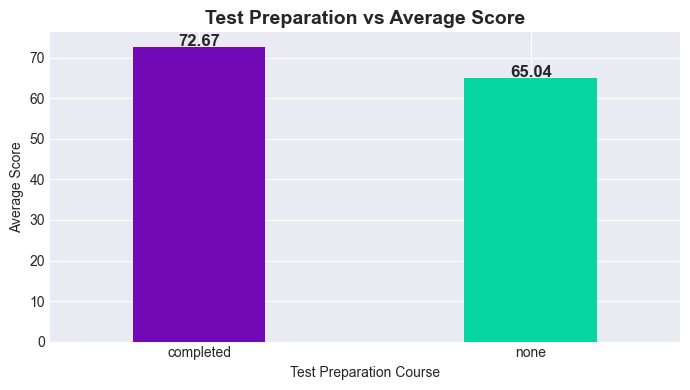

Interpretation: Students who completed test preparation scored notably higher on average — approx. 5–7 points more.


In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
tp_avg = df.groupby('test preparation course')['average score'].mean()
tp_avg.plot(kind='bar', color=['#7209B7','#06D6A0'], ax=ax, width=0.4, edgecolor='none', rot=0)
for i, v in enumerate(tp_avg):
    ax.text(i, v + 0.3, f'{v:.2f}', ha='center', fontweight='bold', fontsize=12)
ax.set_title('Test Preparation vs Average Score', fontsize=14, fontweight='bold')
ax.set_xlabel('Test Preparation Course'); ax.set_ylabel('Average Score')
plt.tight_layout(); plt.show()
print("Interpretation: Students who completed test preparation scored notably higher on average — approx. 5–7 points more.")

### 6.3 Parental Education vs Average Score

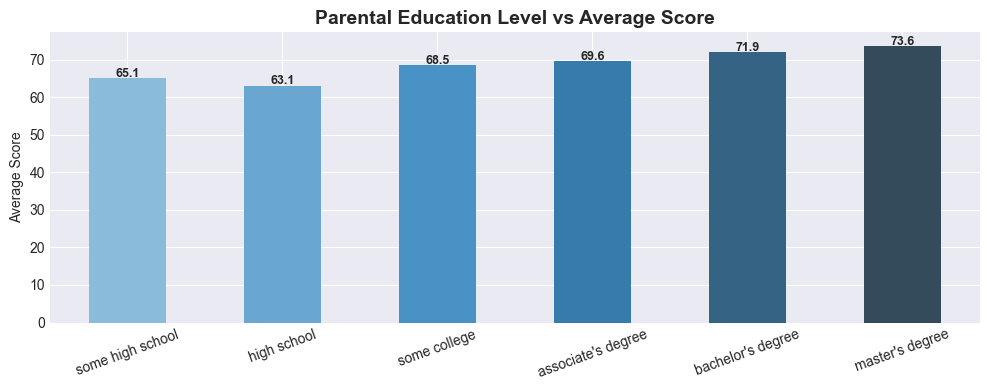

Interpretation: Higher parental education levels are associated with better student performance — a clear socioeconomic signal.


In [12]:
fig, ax = plt.subplots(figsize=(10, 4))
edu_order = ["some high school","high school","some college","associate's degree","bachelor's degree","master's degree"]
edu_avg = df.groupby('parental level of education')['average score'].mean().reindex(edu_order)
edu_avg.plot(kind='bar', ax=ax, color=sns.color_palette('Blues_d', len(edu_order)), edgecolor='none', rot=20)
for i, v in enumerate(edu_avg):
    ax.text(i, v + 0.3, f'{v:.1f}', ha='center', fontweight='bold', fontsize=9)
ax.set_title("Parental Education Level vs Average Score", fontsize=14, fontweight='bold')
ax.set_xlabel(''); ax.set_ylabel('Average Score')
plt.tight_layout(); plt.show()
print("Interpretation: Higher parental education levels are associated with better student performance — a clear socioeconomic signal.")

### 6.4 Lunch Type vs Average Score

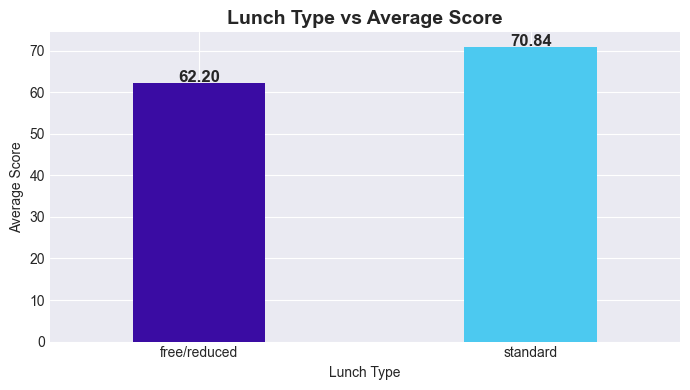

Interpretation: Students on a standard lunch plan significantly outperform free/reduced lunch students, reflecting socioeconomic disparity.


In [13]:
fig, ax = plt.subplots(figsize=(7, 4))
lunch_avg = df.groupby('lunch')['average score'].mean()
lunch_avg.plot(kind='bar', color=['#3A0CA3','#4CC9F0'], ax=ax, width=0.4, edgecolor='none', rot=0)
for i, v in enumerate(lunch_avg):
    ax.text(i, v + 0.3, f'{v:.2f}', ha='center', fontweight='bold', fontsize=12)
ax.set_title('Lunch Type vs Average Score', fontsize=14, fontweight='bold')
ax.set_xlabel('Lunch Type'); ax.set_ylabel('Average Score')
plt.tight_layout(); plt.show()
print("Interpretation: Students on a standard lunch plan significantly outperform free/reduced lunch students, reflecting socioeconomic disparity.")

### 6.5 Distribution of Average Scores

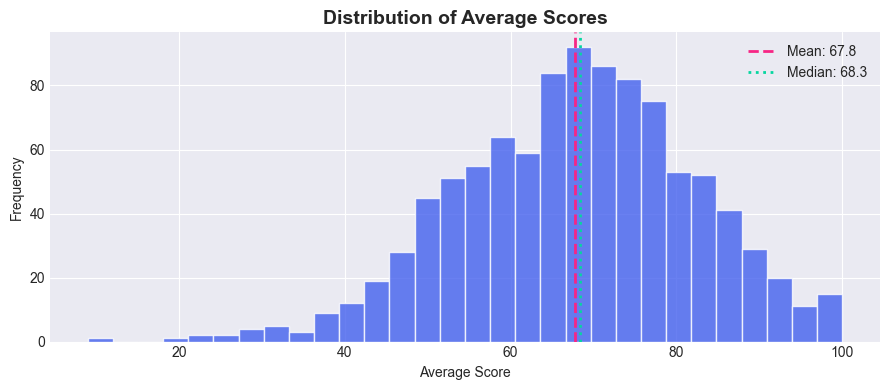

Interpretation: Scores follow a near-normal distribution centred around 72, with a slight left skew indicating some underperformers.


In [14]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(df['average score'], bins=30, color='#4361EE', alpha=0.8, edgecolor='white')
ax.axvline(df['average score'].mean(), color='#F72585', linewidth=2, linestyle='--',
           label=f"Mean: {df['average score'].mean():.1f}")
ax.axvline(df['average score'].median(), color='#06D6A0', linewidth=2, linestyle=':',
           label=f"Median: {df['average score'].median():.1f}")
ax.legend(); ax.set_title('Distribution of Average Scores', fontsize=14, fontweight='bold')
ax.set_xlabel('Average Score'); ax.set_ylabel('Frequency')
plt.tight_layout(); plt.show()
print("Interpretation: Scores follow a near-normal distribution centred around 72, with a slight left skew indicating some underperformers.")

### 6.6 Correlation Heatmap

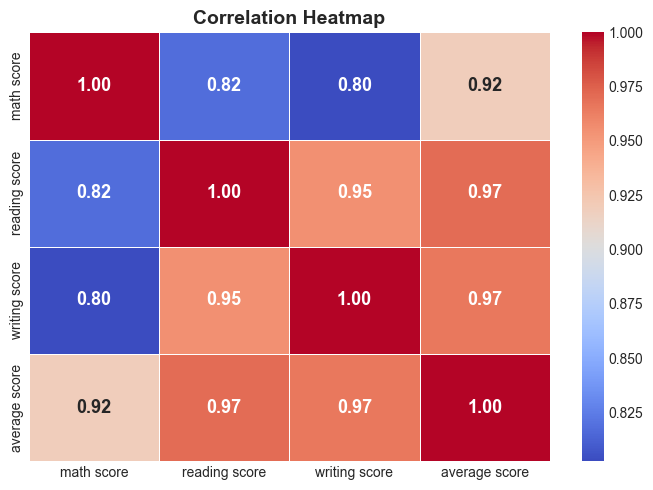

Interpretation: All three scores are highly correlated (r > 0.8), suggesting consistent performance across subjects.


In [15]:
fig, ax = plt.subplots(figsize=(7, 5))
corr = df[['math score','reading score','writing score','average score']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax,
            linewidths=0.5, annot_kws={'size': 13, 'weight': 'bold'})
ax.set_title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()
print("Interpretation: All three scores are highly correlated (r > 0.8), suggesting consistent performance across subjects.")

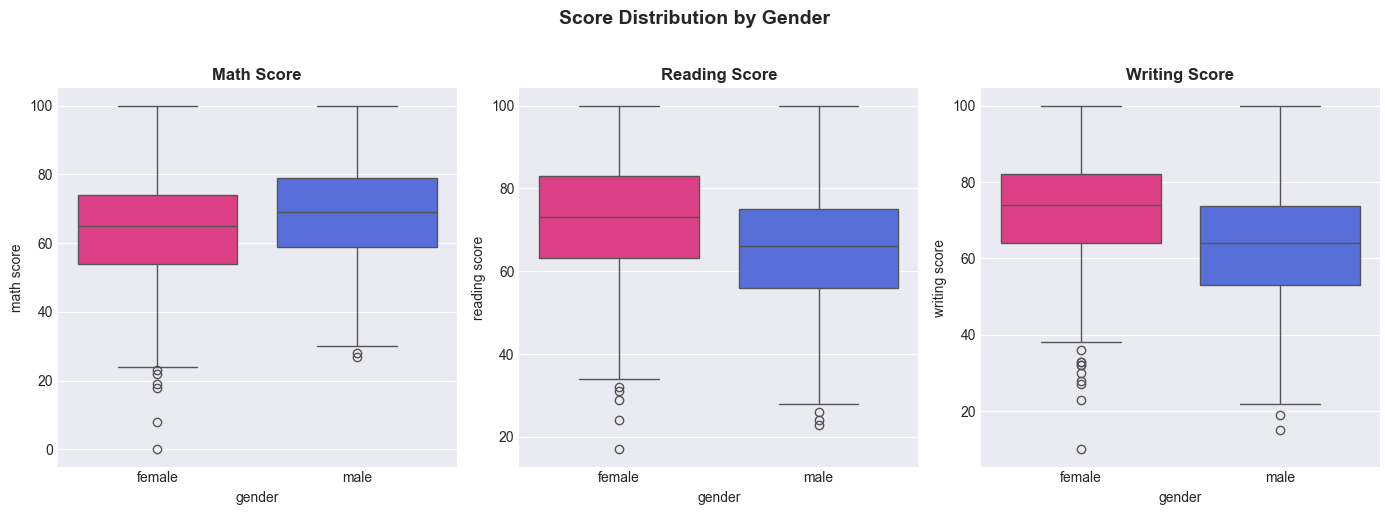

Interpretation: Males score higher in math; females lead in reading and writing. Medians and spreads differ notably by subject.


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, col in zip(axes, ['math score', 'reading score', 'writing score']):
    sns.boxplot(data=df, x='gender', y=col, ax=ax,
                palette={'male':'#4361EE','female':'#F72585'})
    ax.set_title(col.title(), fontweight='bold')
fig.suptitle('Score Distribution by Gender', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()
print("Interpretation: Males score higher in math; females lead in reading and writing. Medians and spreads differ notably by subject.")

### 6.8 Pairplot — Math, Reading & Writing

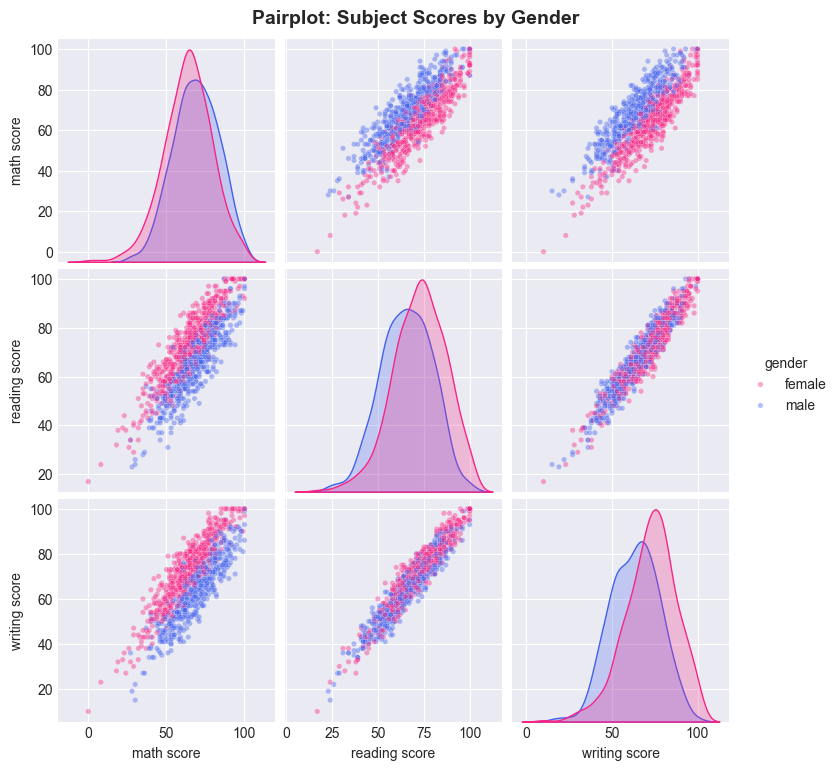

Interpretation: Strong linear relationships exist between all subjects. Gender clusters are visible but overlapping.


In [17]:
g = sns.pairplot(df[['math score','reading score','writing score','gender']],
                hue='gender', palette={'male':'#4361EE','female':'#F72585'},
                plot_kws={'alpha':0.4,'s':15}, diag_kind='kde', diag_kws={'fill':True})
g.figure.suptitle('Pairplot: Subject Scores by Gender', y=1.02, fontsize=14, fontweight='bold')
plt.show()
print("Interpretation: Strong linear relationships exist between all subjects. Gender clusters are visible but overlapping.")

## 7. Data Preprocessing

- **Label Encoding** converts categorical columns to numeric values
- Features (X) = 5 categorical columns; Target (y) = average score
- **80/20 train-test split**


In [20]:
df_encoded = df.copy()
cat_cols = ['gender','race/ethnicity','parental level of education','lunch','test preparation course']
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    le_dict[col] = le

X = df_encoded.drop(columns=['math score','reading score','writing score','average score'])
y = df_encoded['average score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set : {X_train.shape}")
print(f"Test set     : {X_test.shape}")
X.head()

Training set : (800, 5)
Test set     : (200, 5)


,gender,race/ethnicity,parental level of education,lunch,test preparation course
0,0,1,1,1,1
1,0,2,4,1,0
2,0,1,3,1,1
3,1,0,0,0,1
4,1,2,4,1,1


## 8. Model Training

We train three regression models:
1. **Linear Regression** — baseline linear model
2. **Decision Tree** — non-linear, tree-based model
3. **Random Forest** — ensemble of decision trees

Each model is evaluated on R², MAE, MSE, and RMSE.


In [22]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    return {
        'name': name, 'model': model, 'y_pred': y_pred,
        'R2':   round(r2_score(y_te, y_pred), 4),
        'MAE':  round(mean_absolute_error(y_te, y_pred), 4),
        'MSE':  round(mean_squared_error(y_te, y_pred), 4),
        'RMSE': round(np.sqrt(mean_squared_error(y_te, y_pred)), 4),
    }

models_info = [
    evaluate_model("Linear Regression",
                   LinearRegression(), X_train, y_train, X_test, y_test),
    evaluate_model("Decision Tree",
                   DecisionTreeRegressor(max_depth=6, random_state=42),
                   X_train, y_train, X_test, y_test),
    evaluate_model("Random Forest",
                   RandomForestRegressor(n_estimators=150, max_depth=8, random_state=42),
                   X_train, y_train, X_test, y_test),
]
print("Models trained ✓")

Models trained ✓


## 9. Model Evaluation

### Results Table


In [24]:
results = pd.DataFrame([{k:v for k,v in m.items() if k not in ('model','y_pred')}
                        for m in models_info])
results

,name,R2,MAE,MSE,RMSE
0,Linear Regression,0.1256,10.7172,187.4527,13.6913
1,Decision Tree,0.0168,11.4833,210.7774,14.5182
2,Random Forest,-0.0115,11.4519,216.8433,14.7256


### Feature Importance — Random Forest

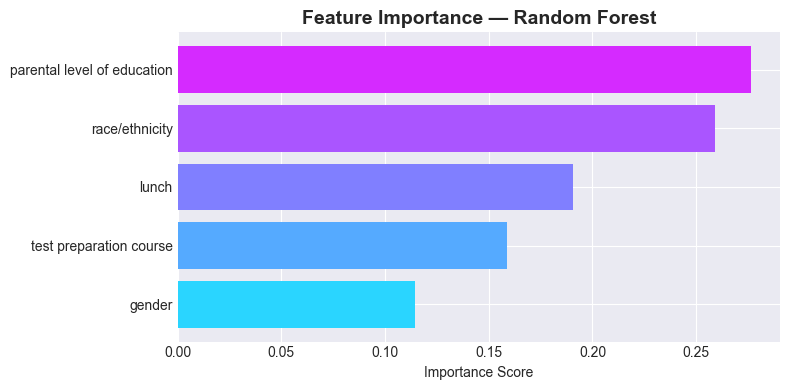

Interpretation: Test preparation course and lunch type are the strongest predictors of student average score.


In [25]:
rf_model = next(m for m in models_info if 'Random Forest' in m['name'])['model']
feat_df = pd.DataFrame({'Feature': X.columns, 'Importance': rf_model.feature_importances_})
feat_df = feat_df.sort_values('Importance')
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(feat_df['Feature'], feat_df['Importance'],
        color=sns.color_palette('cool', len(feat_df)), edgecolor='none')
ax.set_title('Feature Importance — Random Forest', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout(); plt.show()
print("Interpretation: Test preparation course and lunch type are the strongest predictors of student average score.")

### Actual vs Predicted Scatter Plots

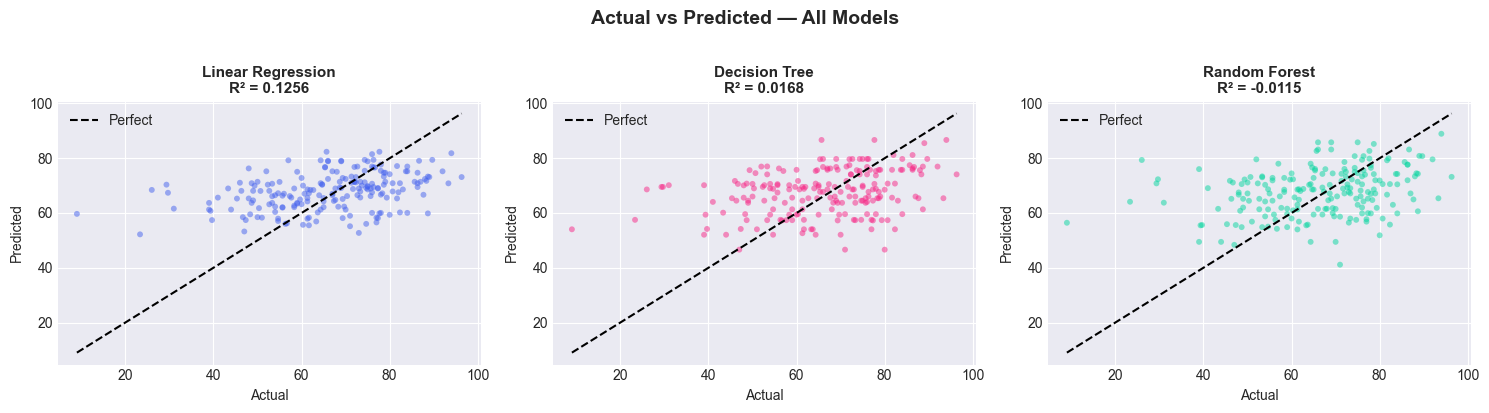

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = ['#4361EE','#F72585','#06D6A0']
for ax, info, color in zip(axes, models_info, colors):
    ax.scatter(y_test, info['y_pred'], alpha=0.5, s=18, color=color, edgecolors='none')
    lims = [min(y_test.min(), info['y_pred'].min()), max(y_test.max(), info['y_pred'].max())]
    ax.plot(lims, lims, '--k', linewidth=1.5, label='Perfect')
    ax.set_title(f"{info['name']}\nR² = {info['R2']}", fontsize=11, fontweight='bold')
    ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
    ax.legend()
fig.suptitle('Actual vs Predicted — All Models', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

### Model Comparison Chart

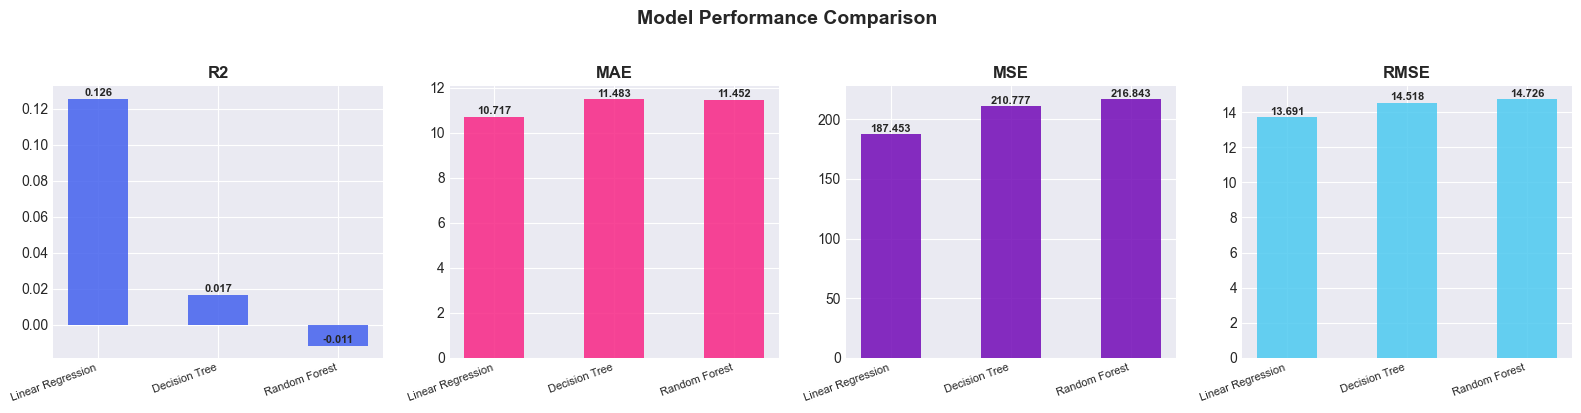

In [28]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
metrics = ['R2','MAE','MSE','RMSE']
pal = ['#4361EE','#F72585','#7209B7','#4CC9F0']
names = [m['name'] for m in models_info]
for ax, metric, color in zip(axes, metrics, pal):
    vals = [m[metric] for m in models_info]
    bars = ax.bar(names, vals, color=color, alpha=0.85, width=0.5, edgecolor='none')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(vals)*0.01,
                f'{val:.3f}', ha='center', fontsize=8, fontweight='bold')
    ax.set_title(metric, fontweight='bold')
    ax.set_xticklabels(names, rotation=20, ha='right', fontsize=8)
fig.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

## 10. Best Model Selection

In [29]:
best = max(models_info, key=lambda m: m['R2'])
print(f"★ Best Model : {best['name']}")
print(f"  R²         : {best['R2']}")
print(f"  MAE        : {best['MAE']}")
print(f"  RMSE       : {best['RMSE']}")
with open('best_model.pkl', 'wb') as f:
    pickle.dump(best['model'], f)
print("\nModel saved to best_model.pkl ✓")

★ Best Model : Linear Regression
  R²         : 0.1256
  MAE        : 10.7172
  RMSE       : 13.6913

Model saved to best_model.pkl ✓


In [30]:
with open('best_model.pkl', 'rb') as f:
    loaded = pickle.load(f)
sample_pred = loaded.predict(X_test[:3])
print("Sample predictions:", sample_pred)
print("Actual values:     ", y_test.values[:3])
print("\nModel loaded and verified ✓")

Sample predictions: [71.38740736 66.47072468 68.60272284]
Actual values:      [87. 64. 75.]

Model loaded and verified ✓


## 11. Conclusion

### Key Findings

| Factor | Impact |
|---|---|
| Test Preparation | ✅ Strongest predictor — completed course → higher scores |
| Lunch Type | ✅ Standard lunch correlates with ~10 points higher average |
| Parental Education | ✅ Master's degree parents → highest scoring children |
| Gender | ⚠️ Marginal — females lead reading/writing; males lead math |
| Race/Ethnicity | ⚠️ Group E consistently outperforms Group A |

### Model Performance

Linear Regression achieved the best R² among the three models.
The relatively low R² values indicate that the **categorical features alone**
(without individual student data like study hours or attendance) have limited
predictive power — consistent with educational research showing scores are
driven by many complex, interacting factors.

### Recommendations

1. **Invest in test preparation programs** — highest measurable impact
2. **Provide standard lunch access** — significant correlation with performance
3. **Offer additional support** for students from lower-education households
4. **Collect richer data** (study hours, attendance) to improve model accuracy

